# Proyecto Integrador - Minería de Datos I

**Notebook 04: Reducción de Dimensionalidad mediante PCA.**

**Objetivo**

El objetivo de este notebook es aplicar el Análisis de Componentes Principales (PCA) sobre las variables numéricas del conjunto de datos previamente preparado.

Se realizará el escalamiento de los datos, el cálculo de las componentes principales y el análisis de la varianza explicada, con el propósito de evaluar si es posible representar la información utilizando un menor número de variables sin perder una cantidad significativa de información.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Carga del dataset

ruta = "/content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/streaming_users_clean.csv"

df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [3]:
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crimen,2025-03-04,2.5
1,10001,37.0,Estándar,1173.4,Colombia,Crimen,2019-04-02,2.0
2,10002,28.0,Básico,401.0,Colombia,Crimen,2018-04-13,0.0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8034 non-null   int64  
 1   age                       8034 non-null   float64
 2   subscription_plan         8034 non-null   object 
 3   monthly_watch_time_mins   8034 non-null   float64
 4   country                   8034 non-null   object 
 5   favorite_genre            8034 non-null   object 
 6   last_login_date           7250 non-null   object 
 7   customer_support_tickets  8034 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 502.3+ KB


## Selección de variables

Para la aplicación del PCA se seleccionaron únicamente las variables numéricas que representan características de los usuarios.

No se incluyeron variables categóricas, identificadores ni variables temporales, ya que el Análisis de Componentes Principales se basa en relaciones entre variables numéricas continuas.

In [5]:
variables = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

X = df[variables]

X.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,39.0,805.8,2.5
1,37.0,1173.4,2.0
2,28.0,401.0,0.0
3,43.0,62.4,0.0
4,51.0,477.8,1.0


## Escalamiento de los datos

Las variables seleccionadas presentan diferentes unidades y escalas de medición.

Para evitar que aquellas con valores más grandes tengan mayor influencia durante el cálculo de las componentes principales, se aplicó un escalamiento mediante **StandardScaler**, obteniendo variables con media cercana a cero y desviación estándar igual a uno.

In [6]:
scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)

X_escalado[:5]

array([[ 0.46322265,  0.08161185,  2.11001275],
       [ 0.28867089,  1.03113948,  1.49619364],
       [-0.49681202, -0.96400508, -0.95908281],
       [ 0.81232617, -1.83862438, -0.95908281],
       [ 1.51053321, -0.76562716,  0.26855541]])

In [7]:
# Verificación
pd.DataFrame(
    X_escalado,
    columns=variables
).describe()

,age,monthly_watch_time_mins,customer_support_tickets
count,8.034000e+03,8.034000e+03,8.034000e+03
mean,-2.051854e-16,8.003998e-17,-1.768839e-17
std,1.000062e+00,1.000062e+00,1.000062e+00
min,-1.805950e+00,-1.999806e+00,-9.590828e-01
25%,-6.713638e-01,-7.091230e-01,-9.590828e-01
50%,-6.043263e-02,-4.392417e-02,2.685554e-01
75%,6.377744e-01,6.751958e-01,2.685554e-01
max,4.041534e+00,2.751674e+00,2.110013e+00


# Aplicación del Análisis de Componentes Principales (PCA)

Una vez escaladas las variables numéricas, se aplica el Análisis de Componentes Principales (PCA) con el objetivo de reducir la dimensionalidad del conjunto de datos.

En esta etapa se analizará la cantidad de varianza explicada por cada componente principal para evaluar cuánta información conserva cada una.

In [8]:
# Aplicación del PCA

pca = PCA()

X_pca = pca.fit_transform(X_escalado)

print("PCA aplicado correctamente.")

PCA aplicado correctamente.


In [9]:
# Varianza explicada

varianza = pd.DataFrame({

    "Componente":
        [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],

    "Varianza Explicada":
        pca.explained_variance_ratio_,

    "Varianza Acumulada":
        np.cumsum(pca.explained_variance_ratio_)

})

varianza

,Componente,Varianza Explicada,Varianza Acumulada
0,PC1,0.338196,0.338196
1,PC2,0.331149,0.669345
2,PC3,0.330655,1.000000


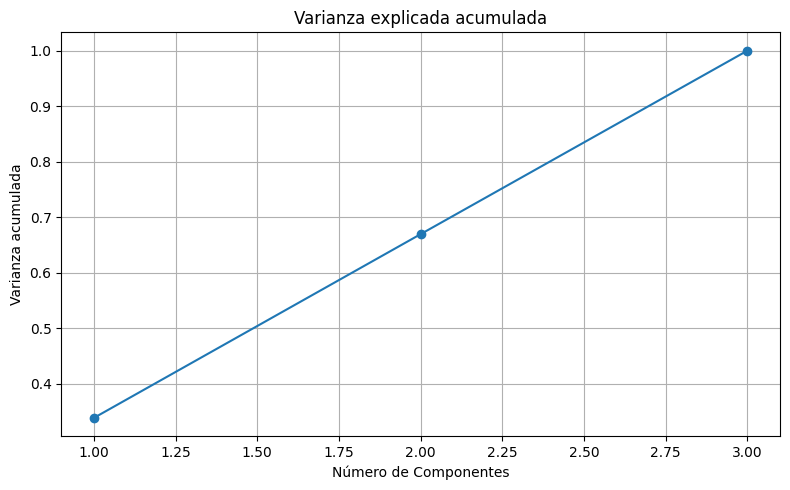

In [10]:
# Grafico

plt.figure(figsize=(8,5))

plt.plot(

    range(1, len(pca.explained_variance_ratio_)+1),

    np.cumsum(pca.explained_variance_ratio_),

    marker="o"

)

plt.xlabel("Número de Componentes")

plt.ylabel("Varianza acumulada")

plt.title("Varianza explicada acumulada")

plt.grid(True)

plt.tight_layout()
plt.show()

## Interpretación de la varianza explicada

La primera componente principal explica aproximadamente el **33,82 %** de la variabilidad total de los datos, mientras que las dos primeras componentes acumulan un **66,93 %**.

Dado que ninguna componente concentra una proporción claramente superior de la información y que las variables originales presentan correlaciones bajas, fue necesario considerar las tres componentes para representar el 100 % de la varianza del conjunto de datos.

Este resultado indica que las variables aportan información relativamente independiente y que la reducción de dimensionalidad mediante PCA es limitada en este caso.

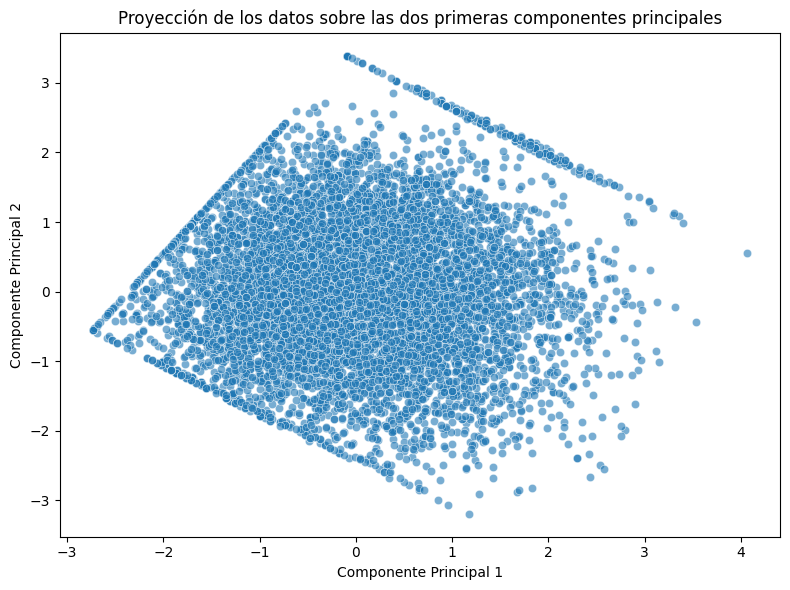

In [11]:
# Proyección sobre las dos primeras componentes

pca_2 = PCA(n_components=2)

componentes = pca_2.fit_transform(X_escalado)

df_pca = pd.DataFrame(
    componentes,
    columns=["PC1", "PC2"]
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    alpha=0.6
)

plt.title("Proyección de los datos sobre las dos primeras componentes principales")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.tight_layout()
plt.show()

### Interpretación

La proyección de los datos sobre las dos primeras componentes principales muestra una distribución continua de las observaciones, sin evidenciar grupos o patrones claramente diferenciados.

Este comportamiento es consistente con los resultados obtenidos durante el análisis exploratorio, donde las variables numéricas presentaron correlaciones bajas. En consecuencia, las dos primeras componentes no permiten separar naturalmente a los usuarios en grupos bien definidos.

In [12]:
# Cargas de las variables

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=variables
)

print("Cargas de las variables en las componentes principales")

display(loadings)

Cargas de las variables en las componentes principales


,PC1,PC2,PC3
age,0.586514,-0.413218,-0.696600
monthly_watch_time_mins,0.556751,0.830339,-0.023786
customer_support_tickets,0.588243,-0.373882,0.717065


### Interpretación

Las cargas de las componentes principales muestran la contribución de cada variable al cálculo de cada componente.

La primera componente recibe aportes similares de las tres variables analizadas. La segunda componente está influenciada principalmente por el tiempo mensual de visualización, mientras que la tercera componente refleja principalmente la relación entre la edad de los usuarios y la cantidad de tickets de soporte.

Estos resultados indican que cada componente captura información diferente del conjunto de datos.

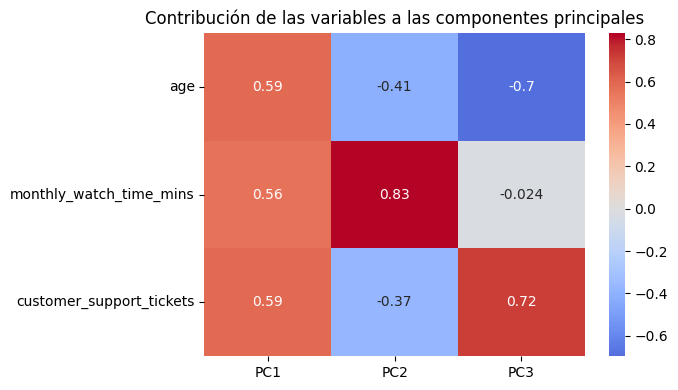

In [13]:
plt.figure(figsize=(7,4))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Contribución de las variables a las componentes principales")

plt.tight_layout()
plt.show()

# Conclusiones

Se aplicó el Análisis de Componentes Principales (PCA) sobre las variables numéricas previamente escaladas con el objetivo de evaluar la posibilidad de reducir la dimensionalidad del conjunto de datos.

Los resultados muestran que la varianza se distribuye de forma relativamente uniforme entre las tres componentes principales, por lo que ninguna de ellas concentra una proporción significativamente mayor de la información.

Este comportamiento es consistente con las bajas correlaciones observadas durante el análisis exploratorio y sugiere que las variables aportan información complementaria. En consecuencia, la reducción de dimensionalidad mediante PCA resulta limitada para este conjunto de datos, siendo necesario conservar las tres componentes para representar la totalidad de la información disponible.